# MLP vs GRU vs LSTM vs Black-Scholes

A deep hedging study on a 30-day at-the-money call, hedged with three neural
architectures (MLP, GRU, LSTM) and compared against Black-Scholes, Leland's
transaction-cost-adjusted Black-Scholes, a naive intrinsic-value hedge, a
logistic-regression hedge, and the unhedged position.

Every hyperparameter (network width, learning rate, epochs) is selected on a
held-out validation split before touching the test set, so the numbers in
Part 7 onward are genuinely out-of-sample.


In [1]:
import os
import random
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, skew, kurtosis
import sklearn as sk

import tensorflow as tf
from tensorflow import keras


In [2]:

import sys
import os


sys.path.append(os.path.abspath('./src'))

In [3]:
from data_loader import download_data, build_windows

In [4]:
# Reproducibility. PYTHONHASHSEED only takes effect on interpreter start, so it
# is set here mainly for documentation / if this notebook is re-launched from a script.
os.environ['PYTHONHASHSEED'] = str(42)
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)


## 0 — Market data, trajectory construction and EDA


In [5]:
# Open prices for SPY and 9 other sector ETFs and world-index trackers
# from 01/01/2006 to 31/12/2025
price_data=download_data()

print(f"\nDataset shape: {price_data.shape[0]} trading days x {price_data.shape[1]} assets")
print(f"Date range   : {price_data.index[0].date()} to {price_data.index[-1].date()}")


[*********************100%***********************]  10 of 10 completed



Dataset shape: 5030 trading days x 10 assets
Date range   : 2006-01-03 to 2025-12-30


In [6]:
import models

num_steps = 30
models.num_steps = num_steps
K = 1.0            # strike price ATM
models.K = K
brokerage_fee = 0.001


SPLITS = {
    "train": ("2006-01-01", "2019-12-31"),
    "val":   ("2020-01-01", "2021-12-31"),
    "test":  ("2022-01-01", "2025-12-31"),
}



train, train_meta = build_windows(price_data, *SPLITS["train"])
val,   val_meta   = build_windows(price_data, *SPLITS["val"])
test,  test_meta  = build_windows(price_data, *SPLITS["test"])

# disjoint versions, for honest confidence intervals later (Part 7.5)
val_disjoint,  _ = build_windows(price_data, *SPLITS["val"],  stride=num_steps + 1)
test_disjoint, _ = build_windows(price_data, *SPLITS["test"], stride=num_steps + 1)

rng = np.random.default_rng(42)
rng.shuffle(train)          # val and test stay ordered for block bootstrap / date attribution

for name, paths, meta, disjoint in [
    ("train", train, train_meta, None),
    ("val",   val,   val_meta,   val_disjoint),
    ("test",  test,  test_meta,  test_disjoint),
]:
    ret = paths[:, -1] - 1.0
    n_eff = len(disjoint) if disjoint is not None else len(paths) // (num_steps + 1)
    print(f"{name:5s} | {SPLITS[name][0]}..{SPLITS[name][1]} | "
          f"{len(paths):6d} windows ({n_eff:4d} disjoint) | "
          f"P(S_T > K) = {100 * (ret > 0).mean():5.1f}% | "
          f"mean 30d return = {ret.mean():+.4f} | std = {ret.std():.4f}")


train | 2006-01-01..2019-12-31 |  34930 windows (1126 disjoint) | P(S_T > K) =  62.5% | mean 30d return = +0.0093 | std = 0.0637
val   | 2020-01-01..2021-12-31 |   4750 windows ( 160 disjoint) | P(S_T > K) =  68.4% | mean 30d return = +0.0227 | std = 0.0985
test  | 2022-01-01..2025-12-31 |   9720 windows ( 320 disjoint) | P(S_T > K) =  58.8% | mean 30d return = +0.0108 | std = 0.0619


Exploratory analysis on the **training period only** (2006–2019), so nothing
about the val/test windows leaks into how we read the data. Eight panels:
the stylized facts of daily returns (fat tails, autocorrelation, volatility
clustering, leverage effect, cross-correlation, cumulative performance), plus
the two panels that describe the 30-day windows the hedgers actually train on
(a sample of paths, and the terminal-return distribution across splits).

*Note: every quantity the eight panels use (`ret_lags`, `conf_limit`, etc.) is
defined up front, before any subplot references it. In one of the two source
notebooks this was defined inside a "return autocorrelation" panel that was
later dropped, which left a downstream panel referencing an undefined name and
silently failing — reproduced and fixed here.*


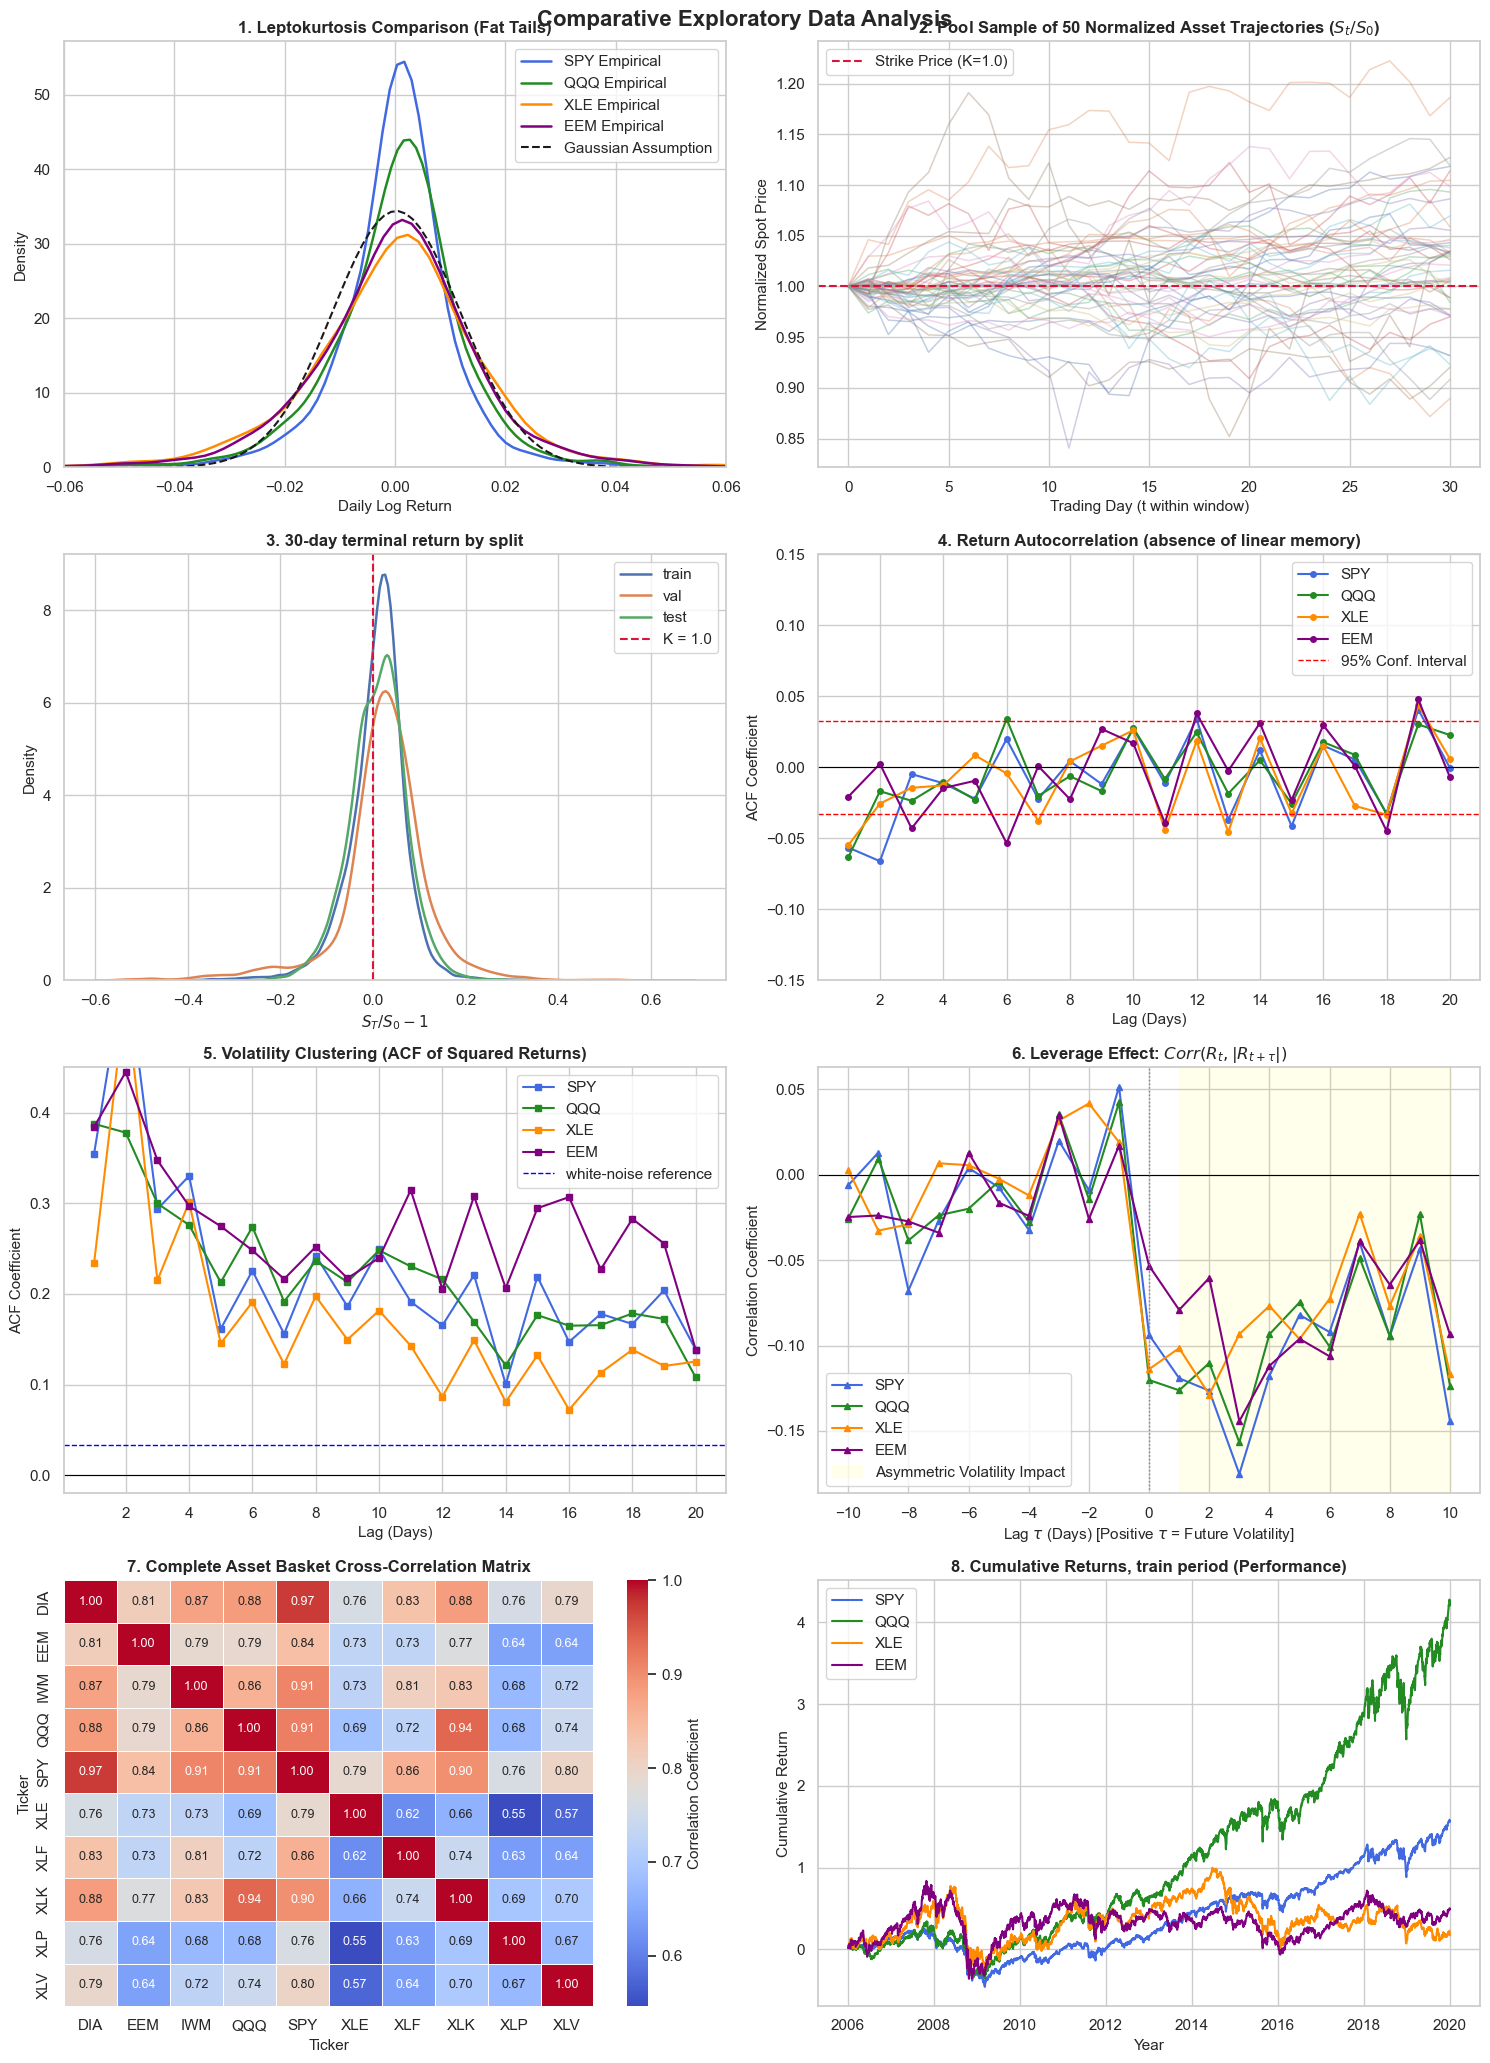


PCA1 importance
mean pairwise correlation: 0.762
PC1 explains 79.0% of variance

Descriptive Statistics Summary
| Asset Ticker   |   Mean (μ) |   Std Dev (σ) |   Skewness |   Excess Kurtosis |
|:---------------|-----------:|--------------:|-----------:|------------------:|
| DIA            |   0.000276 |       0.01077 |     -0.477 |            15.527 |
| EEM            |   0.000113 |       0.01682 |     -0.085 |            11.758 |
| IWM            |   0.000255 |       0.015   |     -0.356 |            11.454 |
| QQQ            |   0.000468 |       0.01292 |     -0.592 |             7.869 |
| SPY            |   0.000267 |       0.01159 |     -0.568 |            15.029 |
| XLE            |   4.5e-05  |       0.01715 |     -0.626 |            11.737 |
| XLF            |   5e-05    |       0.02033 |      0.443 |            21.31  |
| XLK            |   0.000417 |       0.01326 |     -0.639 |            11.415 |
| XLP            |   0.000281 |       0.00971 |     -0.916 |            23.21

In [7]:
# style
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'figure.titlesize': 16,
    'font.family': 'sans-serif'
})
colors = ['royalblue', 'forestgreen', 'darkorange', 'purple']

# log returns, TRAINING PERIOD ONLY (avoids reading conclusions off val/test data)
log_returns = np.log(price_data.loc[SPLITS["train"][0]:SPLITS["train"][1]]).diff().dropna()

# subset for comparison
comp_tickers = ['SPY', 'QQQ', 'XLE', 'EEM']
comp_tickers = [t for t in comp_tickers if t in log_returns.columns]

# everything every subplot needs, defined BEFORE the subplots that use it
max_lag = 20
local_K = 1.0
ret_lags = range(1, max_lag + 1)
conf_limit = 1.96 / np.sqrt(len(log_returns))

fig, axes = plt.subplots(4, 2, figsize=(15, 21))

# SUBPLOT 1: empirical distribution
ax1 = axes[0, 0]
for ticker, color in zip(comp_tickers, colors):
    sns.kdeplot(log_returns[ticker], color=color, linewidth=1.8, ax=ax1, label=f'{ticker} Empirical')

spy_mu, spy_std = norm.fit(log_returns[comp_tickers[0]])
x_axis = np.linspace(log_returns[comp_tickers].min().min(), log_returns[comp_tickers].max().max(), 300)
ax1.plot(x_axis, norm.pdf(x_axis, spy_mu, spy_std), 'k--', linewidth=1.5, label='Gaussian Assumption')

ax1.set_title('1. Leptokurtosis Comparison (Fat Tails)', fontweight='bold')
ax1.set_xlabel('Daily Log Return')
ax1.set_ylabel('Density')
ax1.set_xlim(-0.06, 0.06)
ax1.legend(loc='upper right')

# SUBPLOT 2: trajectory paths
ax2 = axes[0, 1]
valid_train = train[~np.isnan(train).any(axis=1)]
random_indices = np.random.choice(valid_train.shape[0], 50, replace=False)

for idx in random_indices:
    ax2.plot(valid_train[idx], alpha=0.35, linewidth=1.1)
ax2.axhline(local_K, color='crimson', linestyle='--', linewidth=1.5, label=f'Strike Price (K={local_K})')
ax2.set_title('2. Pool Sample of 50 Normalized Asset Trajectories ($S_t / S_0$)', fontweight='bold')
ax2.set_xlabel('Trading Day (t within window)')
ax2.set_ylabel('Normalized Spot Price')
ax2.legend(loc='upper left')

# SUBPLOT 3: distribution of 30-day terminal returns per split
ax3 = axes[1, 0]
for name, paths in [("train", train), ("val", val), ("test", test)]:
    sns.kdeplot(paths[:, -1] - 1.0, ax=ax3, linewidth=1.8, label=name)
ax3.axvline(0, color='crimson', linestyle='--', linewidth=1.5, label='K = 1.0')
ax3.set_title('3. 30-day terminal return by split', fontweight='bold')
ax3.set_xlabel('$S_T / S_0 - 1$')
ax3.set_ylabel('Density')
ax3.legend(loc='upper right')

# SUBPLOT 4: return autocorrelation
ax4 = axes[1, 1]
for ticker, color in zip(comp_tickers, colors):
    acf_vals = [log_returns[ticker].autocorr(lag=l) for l in ret_lags]
    ax4.plot(ret_lags, acf_vals, marker='o', markersize=4, linewidth=1.5, color=color, label=ticker)

ax4.axhline(0, color='black', linestyle='-', linewidth=0.8)
ax4.axhline(conf_limit, color='red', linestyle='--', linewidth=1, label='95% Conf. Interval')
ax4.axhline(-conf_limit, color='red', linestyle='--', linewidth=1)
ax4.set_title('4. Return Autocorrelation (absence of linear memory)', fontweight='bold')
ax4.set_xlabel('Lag (Days)')
ax4.set_ylabel('ACF Coefficient')
ax4.set_xticks(range(2, max_lag + 1, 2))
ax4.set_ylim(-0.15, 0.15)
ax4.legend(loc='upper right')

# SUBPLOT 5: volatility clustering
ax5 = axes[2, 0]
for ticker, color in zip(comp_tickers, colors):
    squared_ret = log_returns[ticker] ** 2
    acf_sq_vals = [squared_ret.autocorr(lag=l) for l in ret_lags]
    ax5.plot(ret_lags, acf_sq_vals, marker='s', markersize=4, linewidth=1.5, color=color, label=ticker)

ax5.axhline(0, color='black', linestyle='-', linewidth=0.8)
ax5.axhline(conf_limit, color='blue', linestyle='--', linewidth=1, label='white-noise reference')
ax5.set_title('5. Volatility Clustering (ACF of Squared Returns)', fontweight='bold')
ax5.set_xlabel('Lag (Days)')
ax5.set_ylabel('ACF Coefficient')
ax5.set_xticks(range(2, max_lag + 1, 2))
ax5.set_ylim(-0.02, 0.45)
ax5.legend(loc='upper right')

# SUBPLOT 6: leverage effect
ax6 = axes[2, 1]
lev_lags = np.arange(-10, 11)

for ticker, color in zip(comp_tickers, colors):
    leverage_vals = []
    for l in lev_lags:
        leverage_vals.append(log_returns[ticker].corr(log_returns[ticker].abs().shift(-l)))
    ax6.plot(lev_lags, leverage_vals, marker='^', markersize=4, linewidth=1.5, color=color, label=ticker)

ax6.axhline(0, color='black', linestyle='-', linewidth=0.8)
ax6.axvline(0, color='gray', linestyle=':', linewidth=1)
ax6.set_title('6. Leverage Effect: $Corr(R_t, |R_{t+\\tau}|)$', fontweight='bold')
ax6.set_xlabel('Lag $\\tau$ (Days) [Positive $\\tau$ = Future Volatility]')
ax6.set_ylabel('Correlation Coefficient')
ax6.set_xticks(np.arange(-10, 11, 2))
ax6.axvspan(1, 10, color='yellow', alpha=0.08, label='Asymmetric Volatility Impact')
ax6.legend(loc='lower left')

# SUBPLOT 7: cross-correlation matrix
ax7 = axes[3, 0]
corr_matrix = log_returns.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.4,
            ax=ax7, cbar_kws={'label': 'Correlation Coefficient'}, annot_kws={"size": 9})
ax7.set_title('7. Complete Asset Basket Cross-Correlation Matrix', fontweight='bold')

# SUBPLOT 8: cumulative returns (added in the merge)
ax8 = axes[3, 1]
cumulative_returns = np.exp(log_returns[comp_tickers].cumsum()) - 1
for ticker, color in zip(comp_tickers, colors):
    ax8.plot(cumulative_returns.index, cumulative_returns[ticker], color=color, linewidth=1.5, label=ticker)
ax8.set_title('8. Cumulative Returns, train period (Performance)', fontweight='bold')
ax8.set_xlabel('Year')
ax8.set_ylabel('Cumulative Return')
ax8.legend(loc='upper left')

plt.suptitle('Comparative Exploratory Data Analysis', fontweight='bold')
plt.tight_layout()
plt.show()


print("\n" + "="*80)
print("PCA1 importance")
print("="*80)
c_mat = log_returns.corr()
off_diag = c_mat.values[np.triu_indices_from(c_mat, k=1)]
eigvals = np.linalg.eigvalsh(c_mat)
print(f"mean pairwise correlation: {off_diag.mean():.3f}")
print(f"PC1 explains {eigvals[-1] / len(c_mat) * 100:.1f}% of variance")
print("=" * 80)

# descriptive statistics
stats_list = []
for col in log_returns.columns:
    col_data = log_returns[col]
    stats_list.append({
        'Asset Ticker': col,
        'Mean (μ)': f"{col_data.mean():.6f}",
        'Std Dev (σ)': f"{col_data.std():.5f}",
        'Skewness': f"{skew(col_data):.3f}",
        'Excess Kurtosis': f"{kurtosis(col_data, fisher=True):.3f}"
    })
df_stats = pd.DataFrame(stats_list)
print("\n" + "="*80)
print("Descriptive Statistics Summary")
print("="*80)
print(df_stats.to_markdown(index=False))
print("=" * 80)


## 1 — Entropic Loss

**Objective**: minimize the P&L

$$
(\delta^{\theta} \cdot S)_T - C_T(\delta^{\theta}) - Z
$$

by choosing the best hedging strategy $\delta^{\theta}$ with neural networks.

The P&L is a random variable and not only a function of the strategy $\delta^{\theta}$ (it cannot be directly optimized). This optimization can only be achieved by some scalar $\rho(-\text{P&L})$ that focuses only on losses and that satisfies some mathematical properties.

A map $\rho:X \rightarrow \mathbb{R}$ is called convex risk measure if it satisfies:

*   convexity;
*   monotonicity: $x\ge y ⇒ \rho(x) \le \rho(y),\ \ \ x,y \in X$;
*   translation invariance: $\rho(x+a)=\rho(x)-a, \ \ \ \forall a\ge 0, \forall x \in X$.

A possible convex risk measures are the Conditional Value at Risk $\text{CVaR}_{\alpha}$ (or Expected Shortfall $\text{ES}_{\alpha}$) or the Entropic Loss. We chose the second one — it's what every hedger below is trained against. CVaR is reported alongside it from Part 7 onward as a second, complementary risk lens.


In [8]:
Risk_Aversion=10
from metrics import entropic_loss

In [9]:
# Shuffle again the training paths into batches of 512.
# drop_remainder=True: a partial last batch would break the train_step
# functions below, which build tensors with a fixed 512 rows.
# Shared by the tuner and by every training loop (MLP, GRU, LSTM, Logistic).
dataset = tf.data.Dataset.from_tensor_slices(train)
dataset = dataset.shuffle(buffer_size=len(train)).batch(512, drop_remainder=True)
#dataset = dataset.batch(512, drop_remainder=True)

# Time-to-maturity grid, shared by every feature map below
tau_seq = tf.constant([(num_steps - t) / num_steps for t in range(num_steps)], dtype=tf.float32)

print(f"{len(train) // 512} batches of 512 per epoch "
      f"({len(train) - (len(train) // 512) * 512} paths dropped to keep a fixed batch size).")


68 batches of 512 per epoch (114 paths dropped to keep a fixed batch size).


## 2 — Hyperparameter selection on the validation set

Parts 3–5 need three numbers each: how wide the network is, how fast Adam moves, and when to stop. Reading them off the test set would make every number from Part 7 onward optimistic; reading them off the training loss alone can't see overfitting. We search them on `val` (2020–2021), which sits strictly between train and test in time, and leave `test` (2022–2025) untouched until Part 7.

**Tuned here**

| hyperparameter | grid | why this one |
|---|---|---|
| learning rate | `3e-4, 1e-3, 3e-3` | the loss is a 30-step recurrence and backpropagation through time is stiff — too high and the delta path oscillates, too low and the network never leaves the flat region around $\delta \approx 0.5$ |
| hidden width | `16, 32, 64` | capacity of the hedging rule; ~35k windows of real data is far less than the millions of simulated paths used in Buehler et al., so width is a real bias–variance choice rather than a free lunch |
| epochs | early stopping, patience 5, cap 30 | the knob that controls overfitting most directly |

Three architectures are tuned **independently** — MLP, GRU, and LSTM each get their own winning `(width, lr, epochs)`, kept in a `BEST` dict keyed by architecture. This matters: a single overall "best model" (picking one winner across all architectures and discarding the rest) would silently turn the "MLP vs GRU vs LSTM" comparison into "whichever won the coin flip vs Black-Scholes" — which is what happened in an earlier draft of this merge and is fixed here.

**Deliberately not tuned.** The risk aversion $\lambda$, the transaction fee, the maturity and the strike are not model hyperparameters — they are the problem statement. $\lambda$ encodes how much the desk dislikes losses and the fee is a market fact; choosing $\lambda$ to minimize a validation loss that is itself *defined* by $\lambda$ is circular, and it would always pick the smallest $\lambda$ on the grid. Part 9 sweeps them and reports how the answer moves instead.

The batch size stays at 512. The entropic loss is estimated *on the mini-batch*, so changing it changes the estimator and not just the gradient noise: a smaller batch sees fewer tail paths and systematically understates the risk.

**Selection criterion.** The entropic loss of the P&L over the whole validation set in one shot — not the mean of per-batch losses, which by Jensen's inequality is a different (and smaller) number.


In [10]:
# ---- feature maps (reused verbatim by Parts 3, 4 and 5) ---------------

from models import mlp_features, rnn_features, make_mlp, make_gru, make_lstm

# ---- the three architectures, with the width left free ----------------

from models import make_mlp, make_gru, make_lstm

# ======================================================================
# Grid search on the validation split. 3 architectures x 3 learning rates
# x 3 widths = 27 runs of at most 30 epochs, so this is the slow cell of
# the notebook. To cut the runtime, shorten LR_GRID / WIDTH_GRID, drop
# an architecture, or lower MAX_EPOCHS — nothing downstream depends on
# the size of the grid, only on BEST[...] having an entry per architecture.
# ======================================================================

ARCHS      = ["MLP", "GRU", "LSTM"]
LR_GRID    = [3e-4, 1e-3, 3e-3]
WIDTH_GRID = [16, 32, 64]
MAX_EPOCHS = 30
PATIENCE   = 5

val_tf = tf.cast(val, tf.float32)


# ---- P&L over a set of paths, shared by training and validation ------
# Written shape-agnostically (tf.zeros_like, not tf.zeros((512, 1))) so the
# same function scores a 512-path batch and the full validation set.

from Evaluation import pnl_paths_mlp, pnl_paths_rnn




BUILDERS = {"MLP":  (make_mlp,  pnl_paths_mlp),
            "GRU":  (make_gru,  pnl_paths_rnn),
            "LSTM": (make_lstm, pnl_paths_rnn)}


# ---- one run: train on `train`, early-stop on `val` -------------------
from Train import fit_one
# ---- run the grid -----------------------------------------------------
records = []

for kind in ARCHS:
    for lr in LR_GRID:
        for width in WIDTH_GRID:
            res = fit_one(kind, width, lr, BUILDERS, dataset, val_tf)
            records.append(res)
            print(f"[{kind:4s}] lr={lr:<7g} width={width:<3d} | "
                  f"val entropic {res['val_entropic']:.6f} "
                  f"| best epoch {res['epochs']:2d} (stopped after {len(res['curve'])})")

df_tune = pd.DataFrame(records).drop(columns="curve")


# ---- pick the winner PER architecture -- never a single overall winner
BEST = {}
for kind in ARCHS:
    sub  = df_tune[df_tune["model"] == kind]
    best = sub.loc[sub["val_entropic"].idxmin()]
    BEST[kind] = {"width":  int(best["width"]),
                  "lr":     float(best["lr"]),
                  "epochs": int(best["epochs"])}

print("\n=================== VALIDATION ENTROPIC LOSS ===================")
display(df_tune.pivot_table(index=["model", "lr"], columns="width",
                            values="val_entropic").round(6))
print("\n=================== SELECTED HYPERPARAMETERS ===================")
for kind, cfg in BEST.items():
    print(f"{kind:4s} | width {cfg['width']:3d} | lr {cfg['lr']:g} | {cfg['epochs']} epochs")
print("================================================================")



[MLP ] lr=0.0003  width=16  | val entropic 0.044636 | best epoch  7 (stopped after 12)
[MLP ] lr=0.0003  width=32  | val entropic 0.044777 | best epoch  2 (stopped after 7)
[MLP ] lr=0.0003  width=64  | val entropic 0.044613 | best epoch  1 (stopped after 6)
[MLP ] lr=0.001   width=16  | val entropic 0.041043 | best epoch 21 (stopped after 26)
[MLP ] lr=0.001   width=32  | val entropic 0.044945 | best epoch  1 (stopped after 6)
[MLP ] lr=0.001   width=64  | val entropic 0.042430 | best epoch 13 (stopped after 18)
[MLP ] lr=0.003   width=16  | val entropic 0.041458 | best epoch  4 (stopped after 9)
[MLP ] lr=0.003   width=32  | val entropic 0.045311 | best epoch  2 (stopped after 7)
[MLP ] lr=0.003   width=64  | val entropic 0.042820 | best epoch  5 (stopped after 10)
[GRU ] lr=0.0003  width=16  | val entropic 0.037908 | best epoch 25 (stopped after 30)
[GRU ] lr=0.0003  width=32  | val entropic 0.037927 | best epoch 16 (stopped after 21)
[GRU ] lr=0.0003  width=64  | val entropic 0.03

width               16        32        64
model lr                                  
GRU   0.0003  0.037908  0.037927  0.037923
      0.0010  0.038071  0.038203  0.038346
      0.0030  0.038584  0.038890  0.038984
LSTM  0.0003  0.038165  0.038009  0.038036
      0.0010  0.038067  0.037753  0.038550
      0.0030  0.038561  0.038045  0.038890
MLP   0.0003  0.044636  0.044777  0.044613
      0.0010  0.041043  0.044945  0.042430
      0.0030  0.041458  0.045311  0.042820


=================== SELECTED HYPERPARAMETERS ===================
MLP  | width  16 | lr 0.001 | 21 epochs
GRU  | width  16 | lr 0.0003 | 25 epochs
LSTM | width  32 | lr 0.001 | 7 epochs


The validation curves below are the whole argument for this section: the selected configuration is the bold one, the dashed line is the epoch early stopping kept. Anything to the right of that line is training the model was still willing to do and the validation set said no to.


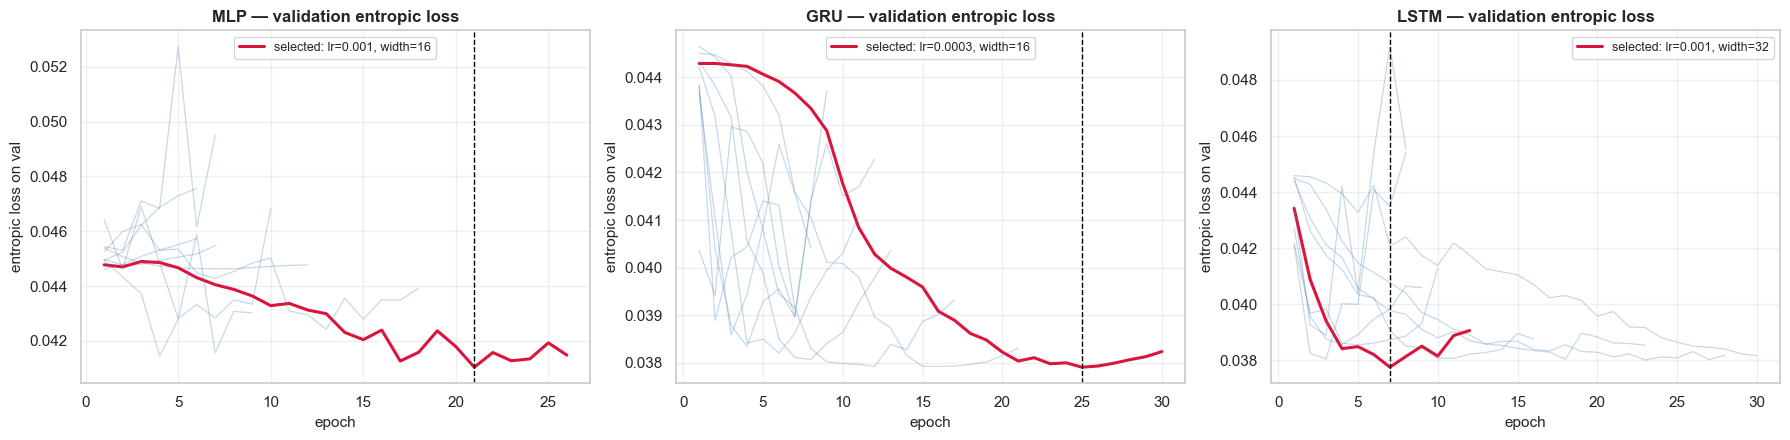

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

for ax, kind in zip(axes, ARCHS):
    for rec in records:
        if rec["model"] != kind:
            continue
        chosen = (rec["width"] == BEST[kind]["width"] and rec["lr"] == BEST[kind]["lr"])
        ax.plot(range(1, len(rec["curve"]) + 1), rec["curve"],
                linewidth=2.2 if chosen else 0.9,
                alpha=1.0 if chosen else 0.30,
                color="crimson" if chosen else "steelblue",
                label=f"selected: lr={rec['lr']:g}, width={rec['width']}" if chosen else None)

    ax.axvline(BEST[kind]["epochs"], color="black", linestyle="--", linewidth=1)
    ax.set_title(f"{kind} — validation entropic loss", fontweight="bold")
    ax.set_xlabel("epoch")
    ax.set_ylabel("entropic loss on val")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 3 — MLP Deep Hedger

Input shape: `(3, )` = ($\delta_{t-1}, S_t, \tau_t$)


In [12]:
# reset seeds
random.seed(42); np.random.seed(42); tf.random.set_seed(42)

# width, learning rate and epochs chosen on the validation set in Part 2
mlp_width  = BEST["MLP"]["width"]
mlp_lr     = BEST["MLP"]["lr"]
mlp_epochs = BEST["MLP"]["epochs"]

hedger_mlp = make_mlp(mlp_width)

optimizer_mlp = keras.optimizers.Adam(learning_rate=mlp_lr)
hedger_mlp.summary()


Model: "sequential_27"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_27 (Lambda)              │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 353 (1.38 KB)

 Trainable params: 353 (1.38 KB)

 Non-trainable params: 0 (0.00 B)

We need to evaluate the hedger at maturity, so we build a function. <br>
The same MLP hedger is called 30 times, it doesn't have separate weigths per time step. It learns a universal hedging rule that takes the previous position, the current price and the time left, and outputs the new position.


In [13]:
# TensorFlow computation graph
from Train import train_step_mlp


`mlp_epochs` epochs — the number early stopping selected on the validation set in Part 2, not a round figure picked by hand. In each epoch all batches of 512 paths.


In [14]:
for epoch in range(mlp_epochs):

    epoch_loss_avg = tf.keras.metrics.Mean()
    epoch_pnl_avg = tf.keras.metrics.Mean()

    for batch in dataset:
        Batch = tf.cast(batch, tf.float32)
        batch_loss, batch_pnl = train_step_mlp(Batch,hedger_mlp,optimizer_mlp)
        epoch_loss_avg.update_state(batch_loss)
        epoch_pnl_avg.update_state(batch_pnl)

    print(f"[MLP] Epoch {epoch+1}/{mlp_epochs} | Entropic Loss: {epoch_loss_avg.result():.6f} | Mean PnL: {epoch_pnl_avg.result():.6f}")


[MLP] Epoch 1/21 | Entropic Loss: 0.027167 | Mean PnL: -0.024091
[MLP] Epoch 2/21 | Entropic Loss: 0.026823 | Mean PnL: -0.023556
[MLP] Epoch 3/21 | Entropic Loss: 0.026705 | Mean PnL: -0.023394
[MLP] Epoch 4/21 | Entropic Loss: 0.026621 | Mean PnL: -0.023288
[MLP] Epoch 5/21 | Entropic Loss: 0.026543 | Mean PnL: -0.023284
[MLP] Epoch 6/21 | Entropic Loss: 0.026465 | Mean PnL: -0.023314
[MLP] Epoch 7/21 | Entropic Loss: 0.026328 | Mean PnL: -0.023292
[MLP] Epoch 8/21 | Entropic Loss: 0.026231 | Mean PnL: -0.023270
[MLP] Epoch 9/21 | Entropic Loss: 0.026105 | Mean PnL: -0.023252
[MLP] Epoch 10/21 | Entropic Loss: 0.025995 | Mean PnL: -0.023282
[MLP] Epoch 11/21 | Entropic Loss: 0.025837 | Mean PnL: -0.023282
[MLP] Epoch 12/21 | Entropic Loss: 0.025656 | Mean PnL: -0.023265
[MLP] Epoch 13/21 | Entropic Loss: 0.025519 | Mean PnL: -0.023207
[MLP] Epoch 14/21 | Entropic Loss: 0.025383 | Mean PnL: -0.023210
[MLP] Epoch 15/21 | Entropic Loss: 0.025232 | Mean PnL: -0.023190
[MLP] Epoch 16/21 |

## 4 — GRU Deep Hedger

Input shape per step: `(2,)` = ($S_t, \tau_t$). No $\delta_{t-1}$ feature is needed here: the GRU's hidden state already carries forward everything about the path so far, including the position implied by it — feeding delta back in explicitly would be redundant (and the network would have to learn to ignore it).


In [15]:
# reset seeds
random.seed(42); np.random.seed(42); tf.random.set_seed(42)

# width, learning rate and epochs chosen on the validation set in Part 2
gru_units  = BEST["GRU"]["width"]
gru_lr     = BEST["GRU"]["lr"]
gru_epochs = BEST["GRU"]["epochs"]

hedger_gru = make_gru(gru_units)

optimizer_gru = keras.optimizers.Adam(learning_rate=gru_lr)
hedger_gru.summary()


Model: "sequential_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_28 (Lambda)              │ (None, 30, 2)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_9 (GRU)                     │ (None, 30, 16)         │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 30, 1)          │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 977 (3.82 KB)

 Trainable params: 977 (3.82 KB)

 Non-trainable params: 0 (0.00 B)

Unlike the MLP, the GRU processes the whole 30-day path in a single vectorized call — `return_sequences=True` returns a delta for every day at once, so there's no Python-level time loop here. The recurrence that matters (today's hedge depends on the whole history so far) happens inside the GRU cell itself, not in this training code.


In [16]:
from Train import train_step_gru


`gru_epochs` epochs — again the number early stopping selected on the validation set in Part 2.


In [17]:
for epoch in range(gru_epochs):

    epoch_loss_avg = tf.keras.metrics.Mean()
    epoch_pnl_avg = tf.keras.metrics.Mean()

    for batch in dataset:
        Batch = tf.cast(batch, tf.float32)
        batch_loss, batch_pnl = train_step_gru(Batch, optimizer_gru, hedger_gru)
        epoch_loss_avg.update_state(batch_loss)
        epoch_pnl_avg.update_state(batch_pnl)

    print(f"[GRU] Epoch {epoch+1}/{gru_epochs} | Entropic Loss: {epoch_loss_avg.result():.6f} | Mean PnL: {epoch_pnl_avg.result():.6f}")


[GRU] Epoch 1/25 | Entropic Loss: 0.026973 | Mean PnL: -0.023871
[GRU] Epoch 2/25 | Entropic Loss: 0.026836 | Mean PnL: -0.023630
[GRU] Epoch 3/25 | Entropic Loss: 0.026795 | Mean PnL: -0.023526
[GRU] Epoch 4/25 | Entropic Loss: 0.026742 | Mean PnL: -0.023420
[GRU] Epoch 5/25 | Entropic Loss: 0.026711 | Mean PnL: -0.023376
[GRU] Epoch 6/25 | Entropic Loss: 0.026710 | Mean PnL: -0.023353
[GRU] Epoch 7/25 | Entropic Loss: 0.026675 | Mean PnL: -0.023391
[GRU] Epoch 8/25 | Entropic Loss: 0.026626 | Mean PnL: -0.023310
[GRU] Epoch 9/25 | Entropic Loss: 0.026548 | Mean PnL: -0.023311
[GRU] Epoch 10/25 | Entropic Loss: 0.026380 | Mean PnL: -0.023286
[GRU] Epoch 11/25 | Entropic Loss: 0.026217 | Mean PnL: -0.023297
[GRU] Epoch 12/25 | Entropic Loss: 0.026098 | Mean PnL: -0.023380
[GRU] Epoch 13/25 | Entropic Loss: 0.026041 | Mean PnL: -0.023300
[GRU] Epoch 14/25 | Entropic Loss: 0.025980 | Mean PnL: -0.023354
[GRU] Epoch 15/25 | Entropic Loss: 0.025941 | Mean PnL: -0.023389
[GRU] Epoch 16/25 |

## 5 — LSTM Deep Hedger

Neither source notebook trained an LSTM — one merge attempt defined an LSTM branch in its model builder but never actually trained or evaluated it. It's added here as a genuine third architecture, tuned in Part 2 exactly like the GRU (own entry in `BEST`, own width/lr/epochs), sharing the GRU's `(S_t, τ_t)` input convention since it's recurrent for the same reason: the cell state already carries the position history.


In [18]:
# reset seeds
random.seed(42); np.random.seed(42); tf.random.set_seed(42)

# width, learning rate and epochs chosen on the validation set in Part 2
lstm_units  = BEST["LSTM"]["width"]
lstm_lr     = BEST["LSTM"]["lr"]
lstm_epochs = BEST["LSTM"]["epochs"]

hedger_lstm = make_lstm(lstm_units)

optimizer_lstm = keras.optimizers.Adam(learning_rate=lstm_lr)
hedger_lstm.summary()


Model: "sequential_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_29 (Lambda)              │ (None, 30, 2)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 30, 32)         │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 30, 1)          │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,513 (17.63 KB)

 Trainable params: 4,513 (17.63 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
from Train import train_step_lstm

In [20]:
for epoch in range(lstm_epochs):

    epoch_loss_avg = tf.keras.metrics.Mean()
    epoch_pnl_avg = tf.keras.metrics.Mean()

    for batch in dataset:
        Batch = tf.cast(batch, tf.float32)
        batch_loss, batch_pnl = train_step_lstm(Batch, hedger_lstm, optimizer_lstm)
        epoch_loss_avg.update_state(batch_loss)
        epoch_pnl_avg.update_state(batch_pnl)

    print(f"[LSTM] Epoch {epoch+1}/{lstm_epochs} | Entropic Loss: {epoch_loss_avg.result():.6f} | Mean PnL: {epoch_pnl_avg.result():.6f}")


[LSTM] Epoch 1/7 | Entropic Loss: 0.026790 | Mean PnL: -0.023533
[LSTM] Epoch 2/7 | Entropic Loss: 0.026357 | Mean PnL: -0.023353
[LSTM] Epoch 3/7 | Entropic Loss: 0.026002 | Mean PnL: -0.023428
[LSTM] Epoch 4/7 | Entropic Loss: 0.025791 | Mean PnL: -0.023371
[LSTM] Epoch 5/7 | Entropic Loss: 0.025724 | Mean PnL: -0.023369
[LSTM] Epoch 6/7 | Entropic Loss: 0.025684 | Mean PnL: -0.023337
[LSTM] Epoch 7/7 | Entropic Loss: 0.025628 | Mean PnL: -0.023305


## 6 — Baselines

Five reference strategies the deep hedgers need to beat:

- **Unhedged**: $\delta \equiv 0$. The floor — anything that doesn't clear this isn't hedging at all.
- **Naive**: $\delta_t = \mathbb{1}\{S_t > K\}$, an all-or-nothing intrinsic-value hedge with no notion of *how far* in or out of the money the option is.
- **Logistic Regression**: the simplest *learned* hedge — a single sigmoid layer on the same $(\delta_{t-1}, S_t, \tau_t)$ features the MLP sees, trained with the same entropic-loss objective and the same feedback loop. It's the control that isolates how much of the deep hedgers' edge comes from network depth versus from the objective/feature setup itself.
- **Black-Scholes**: the textbook answer, $\delta_t = \Phi(d_1)$, using volatility estimated from the training sample rather than an assumed constant — an assumption a live desk couldn't actually verify against the *future*.
- **Leland's correction**: replaces BS's $\sigma$ with a transaction-cost-adjusted $\hat\sigma > \sigma$, so the hedge trades less aggressively when trading itself is costly. It isolates whether cost-awareness alone (without any learning) closes part of the gap to the deep hedgers.


### 6.1 Naive hedger


In [21]:
from Baselines import naive_pnl, unhedged_pnl
from models import make_logistic


### 6.2 Logistic Regression hedger

Same features and the same feedback loop as the MLP — $(\delta_{t-1}, S_t, \tau_t)$ in, one sigmoid unit out, trained on the same entropic loss. The only difference from the MLP is depth: one linear layer instead of two hidden ReLU layers. Whatever gap remains between this and the MLP is attributable to network capacity rather than to the objective or the features.

**The feature order below is `[delta_prev, S_t, tau_t]` — the exact order used during training, in every place this model is called.** Getting this wrong doesn't crash anything (the model still runs, still outputs a number in $[0,1]$), it just silently trains an entropic-loss-minimizing function of $(\delta_{t-1}, S_t, \tau_t)$ and then evaluates it as if it were a function of $(S_t, \tau_t, \delta_{t-1})$ — a different function of the same three numbers. That mismatch was present in two of the four places the logistic hedger was called in the source material (the standalone out-of-sample evaluation and the single-path day-by-day plot) while the other two (the training loop and the parameter-sweep trainer) had it right — which is why it went unnoticed rather than throwing an error. Keeping one `logistic_features` helper and reusing it everywhere below is the fix.


In [22]:
# reset seeds
random.seed(42); np.random.seed(42); tf.random.set_seed(42)

logistic_epochs = 50
logistic_lr = 1e-3

hedger_logistic = make_logistic()

# 1. CORREZIONE: L'ottimizzatore richiede solo il learning rate
optimizer_logistic = keras.optimizers.Adam(learning_rate=logistic_lr)

hedger_logistic.summary()

from Train import train_step_logistic

for epoch in range(logistic_epochs):
    epoch_loss_avg = tf.keras.metrics.Mean()
    epoch_pnl_avg = tf.keras.metrics.Mean()

    for batch in dataset:
        Batch = tf.cast(batch, tf.float32)

        # 2. CORREZIONE: Passa il modello e l'ottimizzatore alla funzione di train
        batch_loss, batch_pnl = train_step_logistic(Batch, hedger_logistic, optimizer_logistic)

        epoch_loss_avg.update_state(batch_loss)
        epoch_pnl_avg.update_state(batch_pnl)

    print(f"[Logistic] Epoch {epoch+1}/{logistic_epochs} | Entropic Loss: {epoch_loss_avg.result():.6f} | Mean PnL: {epoch_pnl_avg.result():.6f}")

Model: "sequential_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_30 (Lambda)              │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (16.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

[Logistic] Epoch 1/50 | Entropic Loss: 0.026979 | Mean PnL: -0.023418
[Logistic] Epoch 2/50 | Entropic Loss: 0.026964 | Mean PnL: -0.023391
[Logistic] Epoch 3/50 | Entropic Loss: 0.026964 | Mean PnL: -0.023377
[Logistic] Epoch 4/50 | Entropic Loss: 0.026918 | Mean PnL: -0.023370
[Logistic] Epoch 5/50 | Entropic Loss: 0.026931 | Mean PnL: -0.023342
[Logistic] Epoch 6/50 | Entropic Loss: 0.026918 | Mean PnL: -0.023336
[Logistic] Epoch 7/50 | Entropic Loss: 0.026909 | Mean PnL: -0.023318
[Logistic] Epoch 8/50 | Entropic Loss: 0.026901 | Mean PnL: -0.023316
[Logistic] Epoch 9/50 | Entropic Loss: 0.026871 | Mean PnL: -0.023298
[Logistic] Epoch 10/50 | Entropic Loss: 0.026869 | Mean PnL: -0.023266
[Logistic] Epoch 11/50 | Entropic Loss: 0.026867 | Mean PnL: -0.023315
[Logistic] Epoch 12/50 | Entropic Loss: 0.026864 | Mean PnL: -0.023287
[Logistic] Epoch 13/50 | Entropic Loss: 0.026850 | Mean PnL: -0.023299
[Logistic] Epoch 14/50 | Entropic Loss: 0.026805 | Mean PnL: -0.023235
[Logistic] Epoc

In [23]:
from Evaluation import logistic_pnl


### 6.3 Black-Scholes and Leland's correction

$$
\delta_t^{BS} = \Phi(d_1), \qquad d_1 = \frac{\ln(S_t/K) + (r + \tfrac{1}{2}\sigma^2)\tau_t}{\sigma\sqrt{\tau_t}}
$$

$\sigma$ is the annualized volatility of the **training-period** daily log returns (Part 0) — estimated from data actually available at the time, not assumed. $r$ is a standard risk-free proxy.

Leland (1985) replaces $\sigma$ with $\hat\sigma$, adjusted upward for the cost of rebalancing at frequency $\Delta t$:

$$
\hat\sigma^2 = \sigma^2\left(1 + \sqrt{\frac{2}{\pi}}\cdot\frac{c}{\sigma\sqrt{\Delta t}}\right), \qquad c = \text{brokerage\_fee}
$$

A higher $\hat\sigma$ pushes $\delta$ closer to 0 or 1 (further from the costly, high-turnover $\delta\approx0.5$ region near the strike), which is exactly the direction a cost-aware hedger should move without needing to learn anything — it's a closed-form correction, not a network.


In [24]:
r_riskfree = 0.045   # standard risk-free proxy, matches the source notebooks

from Baselines import bs_delta, bs_pnl, unhedged_pnl, naive_pnl


# historical volatility, estimated on TRAIN ONLY (same discipline as the EDA in Part 0)
train_log_returns = np.log(train[:, 1:] / train[:, :-1])
hist_sigma = float(np.std(train_log_returns) * np.sqrt(252))

# Leland's transaction-cost-adjusted volatility
dt = 1.0 / 252
leland_sigma = float(np.sqrt(
    hist_sigma**2 * (1 + np.sqrt(2 / np.pi) * (brokerage_fee / (hist_sigma * np.sqrt(dt))))
))

print(f"historical sigma (annualized, train only): {hist_sigma:.4f}")
print(f"Leland sigma (cost-adjusted):               {leland_sigma:.4f}")



historical sigma (annualized, train only): 0.2265
Leland sigma (cost-adjusted):               0.2328


## 7 — Out-of-sample testing: full comparison

Everything below runs on `test` (2022–2025) — data none of the eight strategies has seen, either for training (MLP, GRU, LSTM, Logistic) or for fitting $\hat\sigma$ (BS, Leland).

Two risk metrics side by side: **entropic loss**, the actual training objective, and **CVaR at 95%**, the average loss in the worst 5% of outcomes — a more standard, easier-to-communicate tail measure that the entropic loss doesn't directly report.


In [25]:
from metrics import calculate_cvar




pnl_mlp,      delta_mlp_test      = pnl_paths_mlp(hedger_mlp,  tf.cast(test, tf.float32)), None
pnl_gru_t     = pnl_paths_rnn(hedger_gru,  tf.cast(test, tf.float32))
pnl_lstm_t    = pnl_paths_rnn(hedger_lstm, tf.cast(test, tf.float32))
pnl_mlp       = pnl_mlp.numpy().flatten()
pnl_gru       = pnl_gru_t.numpy().flatten()
pnl_lstm      = pnl_lstm_t.numpy().flatten()
pnl_naive     = naive_pnl(test)
pnl_unhedged  = unhedged_pnl(test)
pnl_logistic  = logistic_pnl(hedger_logistic, test)
pnl_bs        = bs_pnl(test, sigma=hist_sigma)
pnl_leland    = bs_pnl(test, sigma=leland_sigma)

results = {
    "MLP":      pnl_mlp,
    "GRU":      pnl_gru,
    "LSTM":     pnl_lstm,
    "Black-Scholes": pnl_bs,
    "Leland":   pnl_leland,
    "Naive":    pnl_naive,
    "Logistic": pnl_logistic,
    "Unhedged": pnl_unhedged,
}

summary = pd.DataFrame({
    name: {
        "Mean PnL":      np.mean(pnl),
        "Std":           np.std(pnl),
        "Entropic Loss": float(entropic_loss(pnl, Risk_Aversion)),
        "CVaR 95%":      calculate_cvar(pnl),
    }
    for name, pnl in results.items()
}).T.sort_values("Entropic Loss")

print("=" * 78)
print("OUT-OF-SAMPLE COMPARISON (test: 2022-2025)")
print("=" * 78)
display(summary.round(5))

for name, pnl in results.items():
    print(f"{name:14s} | Mean PnL: {np.mean(pnl):+.4f} | Entropic Loss: {float(entropic_loss(pnl, Risk_Aversion)):.4f} | "
          f"std: {np.std(pnl):.4f} | CVaR95: {calculate_cvar(pnl):.4f}")


OUT-OF-SAMPLE COMPARISON (test: 2022-2025)


,Mean PnL,Std,Entropic Loss,CVaR 95%
MLP,-0.02457,0.01441,0.02570,0.06451
LSTM,-0.02457,0.01682,0.02612,0.07181
GRU,-0.02472,0.01609,0.02613,0.06969
Logistic,-0.02434,0.01949,0.02645,0.07996
Leland,-0.02794,0.01176,0.02867,0.05971
Black-Scholes,-0.02796,0.01177,0.02868,0.05995
Naive,-0.02824,0.02481,0.03176,0.09858
Unhedged,-0.03001,0.03903,0.03991,0.14099


MLP            | Mean PnL: -0.0246 | Entropic Loss: 0.0257 | std: 0.0144 | CVaR95: 0.0645
GRU            | Mean PnL: -0.0247 | Entropic Loss: 0.0261 | std: 0.0161 | CVaR95: 0.0697
LSTM           | Mean PnL: -0.0246 | Entropic Loss: 0.0261 | std: 0.0168 | CVaR95: 0.0718
Black-Scholes  | Mean PnL: -0.0280 | Entropic Loss: 0.0287 | std: 0.0118 | CVaR95: 0.0600
Leland         | Mean PnL: -0.0279 | Entropic Loss: 0.0287 | std: 0.0118 | CVaR95: 0.0597
Naive          | Mean PnL: -0.0282 | Entropic Loss: 0.0318 | std: 0.0248 | CVaR95: 0.0986
Logistic       | Mean PnL: -0.0243 | Entropic Loss: 0.0265 | std: 0.0195 | CVaR95: 0.0800
Unhedged       | Mean PnL: -0.0300 | Entropic Loss: 0.0399 | std: 0.0390 | CVaR95: 0.1410


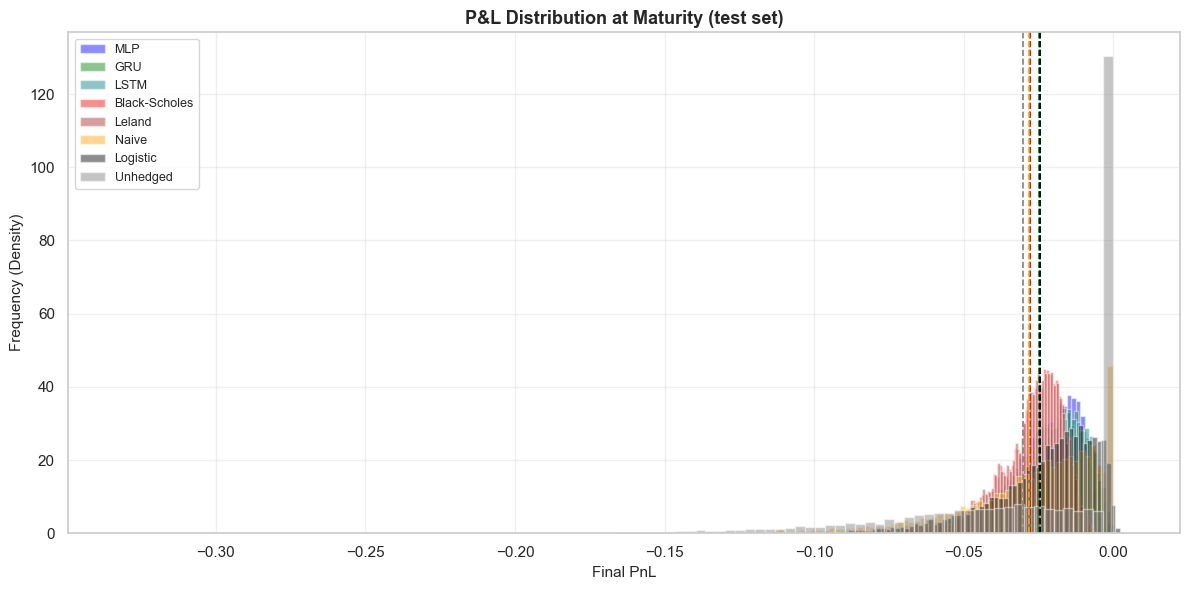

In [26]:
plt.figure(figsize=(12, 6))

hist_colors = {
    "Unhedged": "gray", "Naive": "orange", "Logistic": "black",
    "Black-Scholes": "red", "Leland": "brown",
    "MLP": "blue", "GRU": "green", "LSTM": "teal",
}
for name, pnl in results.items():
    plt.hist(pnl, bins=100, alpha=0.45, label=name, color=hist_colors[name], density=True)
    plt.axvline(np.mean(pnl), color=hist_colors[name], linestyle='dashed', linewidth=1.2)

plt.title('P&L Distribution at Maturity (test set)', fontsize=13, fontweight='bold')
plt.xlabel('Final PnL')
plt.ylabel('Frequency (Density)')
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 7.5 — Statistical validation: bootstrap confidence intervals

The `test` windows overlap (30-day slices with a 1-day stride), so consecutive rows share 29 of their 30 prices — treating them as independent observations understates the sampling uncertainty. Bootstrapping on `test_disjoint` (non-overlapping windows, built in Part 0) gives an honest confidence interval on the entropic loss, for all eight strategies.


MLP            | entropic loss 0.02729   90% CI [0.02553, 0.02899]  (n=320 disjoint windows)
GRU            | entropic loss 0.02732   90% CI [0.02531, 0.02923]  (n=320 disjoint windows)
LSTM           | entropic loss 0.02733   90% CI [0.02531, 0.02925]  (n=320 disjoint windows)
Black-Scholes  | entropic loss 0.02931   90% CI [0.02807, 0.03049]  (n=320 disjoint windows)
Leland         | entropic loss 0.02929   90% CI [0.02806, 0.03047]  (n=320 disjoint windows)
Naive          | entropic loss 0.03288   90% CI [0.03001, 0.03581]  (n=320 disjoint windows)
Logistic       | entropic loss 0.02880   90% CI [0.02624, 0.03116]  (n=320 disjoint windows)
Unhedged       | entropic loss 0.04172   90% CI [0.03534, 0.04790]  (n=320 disjoint windows)


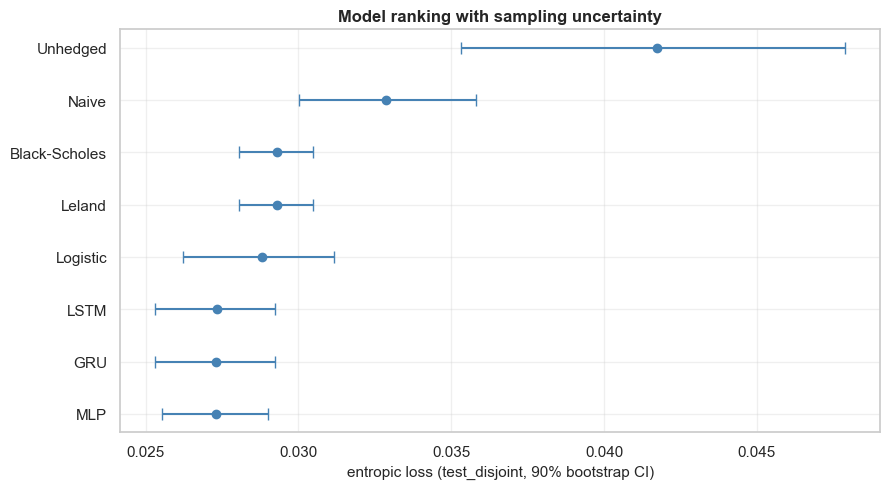

In [27]:
from Evaluation import bootstrap_entropic_ci


test_disjoint_tf = tf.cast(test_disjoint, tf.float32)

boot_fns = {
    "MLP":           lambda d: pnl_paths_mlp(hedger_mlp, tf.cast(d, tf.float32)).numpy().flatten(),
    "GRU":           lambda d: pnl_paths_rnn(hedger_gru, tf.cast(d, tf.float32)).numpy().flatten(),
    "LSTM":          lambda d: pnl_paths_rnn(hedger_lstm, tf.cast(d, tf.float32)).numpy().flatten(),
    "Black-Scholes": lambda d: bs_pnl(d, sigma=hist_sigma),
    "Leland":        lambda d: bs_pnl(d, sigma=leland_sigma),
    "Naive":         lambda d: naive_pnl(d),
    "Logistic":      lambda d: logistic_pnl(hedger_logistic, d),
    "Unhedged":      lambda d: unhedged_pnl(d),
}

boot_records = []
for name, fn in boot_fns.items():
    mean_loss, lo, hi = bootstrap_entropic_ci(fn, test_disjoint)
    boot_records.append({"model": name, "mean_entropic": mean_loss, "ci_low": lo, "ci_high": hi})
    print(f"{name:14s} | entropic loss {mean_loss:.5f}   90% CI [{lo:.5f}, {hi:.5f}]  (n={len(test_disjoint)} disjoint windows)")

df_boot = pd.DataFrame(boot_records).sort_values("mean_entropic")

plt.figure(figsize=(9, 5))
y_pos = np.arange(len(df_boot))
plt.errorbar(df_boot["mean_entropic"], y_pos,
             xerr=[df_boot["mean_entropic"] - df_boot["ci_low"], df_boot["ci_high"] - df_boot["mean_entropic"]],
             fmt='o', capsize=4, color="steelblue")
plt.yticks(y_pos, df_boot["model"])
plt.xlabel("entropic loss (test_disjoint, 90% bootstrap CI)")
plt.title("Model ranking with sampling uncertainty", fontweight="bold")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [28]:
# Same recurrence as pnl_paths_mlp / pnl_paths_rnn (Part 2), but also returning the
# full delta path -- needed for the day-by-day plots (Part 8) and the turnover
# metric in the parameter sweeps (Part 9).

from Evaluation import eval_mlp_with_deltas, eval_rnn_with_deltas


## 8 — Day-by-day hedge output

Aggregate loss numbers hide *how* a strategy hedges. This section looks at one path in detail, then the average hedge ratio across the whole test set.

Leland is left out of both plots below: since it's the same closed-form $\Phi(d_1)$ as Black-Scholes with a slightly larger $\hat\sigma$, its delta path sits almost exactly on top of the BS line and would only add clutter — it's fully present in the tables above and the sweeps below, where the (small) difference it makes is the actual point.


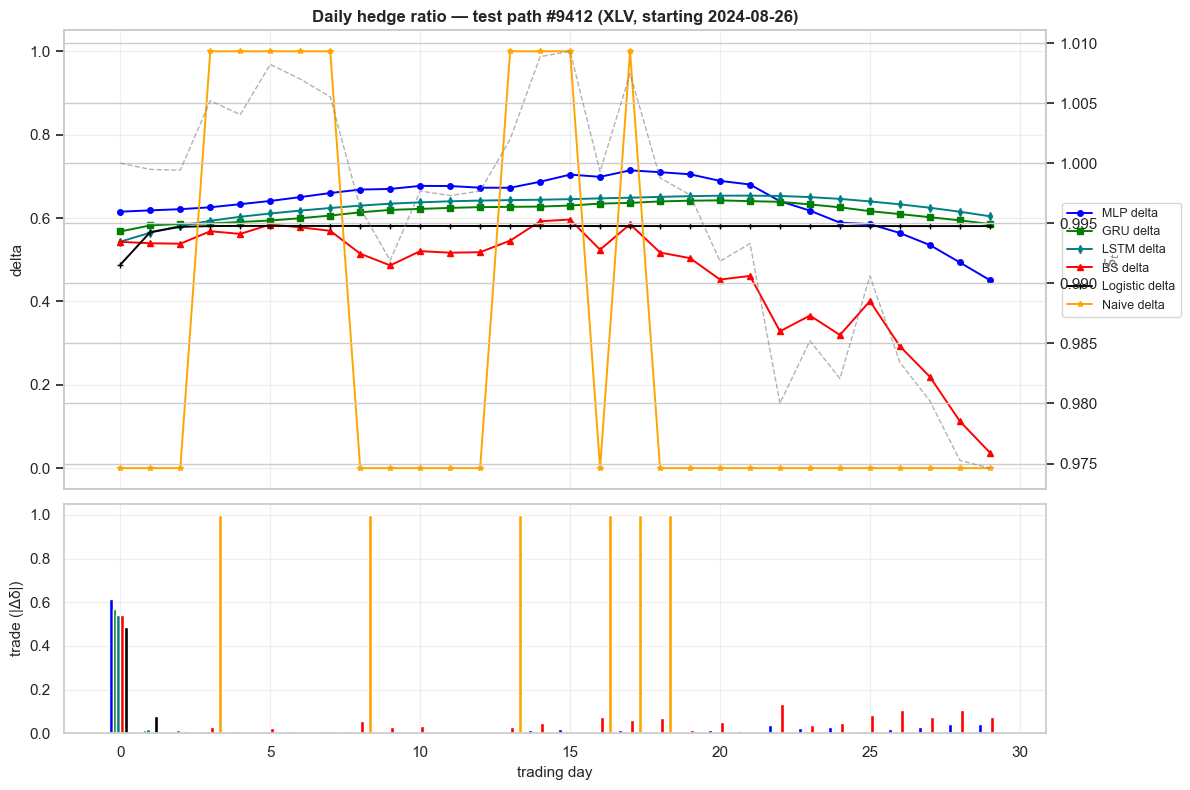

In [29]:
# pick one test path to inspect in detail
np.random.seed(7)
path_idx = np.random.randint(0, len(test))
path = test[path_idx:path_idx+1]

_, delta_mlp_path      = eval_mlp_with_deltas(hedger_mlp, path)
_, delta_gru_path      = eval_rnn_with_deltas(hedger_gru, path)
_, delta_lstm_path     = eval_rnn_with_deltas(hedger_lstm, path)
_, delta_naive_path    = naive_pnl(path, return_deltas=True)
_, delta_logistic_path = logistic_pnl(hedger_logistic, path, return_deltas=True)
_, delta_bs_path       = bs_pnl(path, sigma=hist_sigma, return_deltas=True)

path_np = path[0]
days = np.arange(num_steps)

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(12, 8), sharex=True,
                                      gridspec_kw={'height_ratios': [2, 1]})

series = [
    ("MLP delta",      delta_mlp_path[0],      'blue',   'o'),
    ("GRU delta",      delta_gru_path[0],       'green',  's'),
    ("LSTM delta",     delta_lstm_path[0],      'teal',   'd'),
    ("BS delta",       delta_bs_path[0],        'red',    '^'),
    ("Logistic delta", delta_logistic_path[0],  'black',  '+'),
    ("Naive delta",    delta_naive_path[0],     'orange', '*'),
]

for name, d, color, marker in series:
    ax_top.plot(days, d, marker=marker, markersize=4, linewidth=1.4, color=color, label=name)

ax_top.set_ylabel('delta')
ax_top.set_title(f'Daily hedge ratio — test path #{path_idx} ({test_meta.iloc[path_idx]["ticker"]}, '
                  f'starting {test_meta.iloc[path_idx]["start_date"].date()})', fontweight='bold')
ax_top.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=9)
ax_top.grid(alpha=0.3)

ax_price = ax_top.twinx()
ax_price.plot(days, path_np[:-1], color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax_price.set_ylabel('$S_t$', color='gray')

for name, d, color, marker in series:
    d_prev = np.concatenate([[0.0], d[:-1]])
    trade = np.abs(d - d_prev)
    ax_bot.bar(days + (["MLP delta","GRU delta","LSTM delta","BS delta","Logistic delta","Naive delta"].index(name) - 2.5) * 0.13,
               trade, width=0.13, color=color, label=name)

ax_bot.set_xlabel('trading day')
ax_bot.set_ylabel('trade (|Δδ|)')
ax_bot.grid(alpha=0.3)

plt.tight_layout()
plt.show()


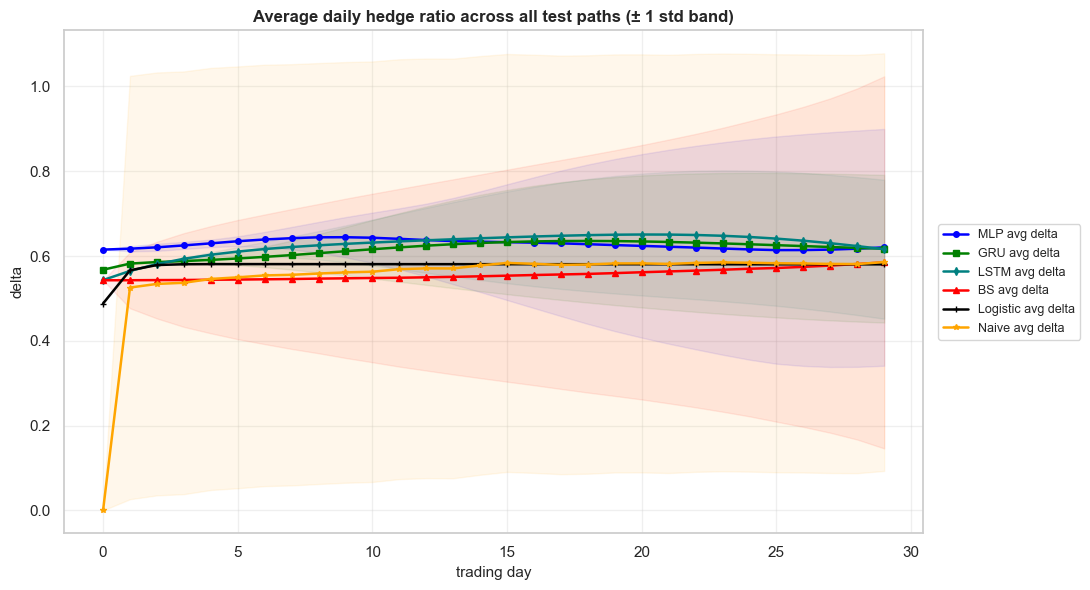

In [30]:
_, deltas_mlp_all      = eval_mlp_with_deltas(hedger_mlp, test)
_, deltas_gru_all      = eval_rnn_with_deltas(hedger_gru, test)
_, deltas_lstm_all     = eval_rnn_with_deltas(hedger_lstm, test)
_, deltas_naive_all    = naive_pnl(test, return_deltas=True)
_, deltas_logistic_all = logistic_pnl(hedger_logistic, test, return_deltas=True)
_, deltas_bs_all       = bs_pnl(test, sigma=hist_sigma, return_deltas=True)

plt.figure(figsize=(11, 6))

avg_series = [
    ("MLP avg delta",      deltas_mlp_all,      'blue',   'o'),
    ("GRU avg delta",      deltas_gru_all,       'green',  's'),
    ("LSTM avg delta",     deltas_lstm_all,      'teal',   'd'),
    ("BS avg delta",       deltas_bs_all,        'red',    '^'),
    ("Logistic avg delta", deltas_logistic_all,  'black',  '+'),
    ("Naive avg delta",    deltas_naive_all,     'orange', '*'),
]

for name, d, color, marker in avg_series:
    mean_d = d.mean(axis=0)
    std_d = d.std(axis=0)
    plt.plot(days, mean_d, marker=marker, markersize=4, linewidth=1.8, color=color, label=name)
    plt.fill_between(days, mean_d - std_d, mean_d + std_d, color=color, alpha=0.08)

plt.xlabel('trading day')
plt.ylabel('delta')
plt.title('Average daily hedge ratio across all test paths (± 1 std band)', fontweight='bold')
plt.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 9 — Performance varying parameters

Fixed choices so far — $\lambda=10$, fee = 10 bps, 30-day maturity — are exactly the parameters Part 2 deliberately did *not* tune (see the note there on why tuning them on a validation loss they themselves define would be circular). This section instead re-trains at each setting and reports how the ranking moves, which is the honest way to answer "does this conclusion depend on the fee level assumed?"

Retraining happens for every neural/learned model (MLP, GRU, LSTM, Logistic) at every grid point — Black-Scholes, Leland, Naive and Unhedged need no retraining since they have no learned parameters, only their formulas depend on the swept quantity.


### 9.1 Reusable trainers and `run_config`

One trainer per learnable architecture, parameterized by `(n_steps, K, fee, risk_aversion)` so the same function serves all three sweeps below. `sweep_epochs` is deliberately smaller than the early-stopped epoch counts from Part 2 — retraining 4 models at every one of ~12 grid points is already the slow part of the notebook; raise it if you have the time budget.


In [31]:
sweep_epochs = 20

from Train import train_mlp_cfg, train_rnn_cfg, train_gru_cfg, train_logistic_cfg, train_lstm_cfg


In [32]:
def sweep_metrics(pnl, risk_aversion, deltas=None):
    row = {
        "mean": float(np.mean(pnl)),
        "std": float(np.std(pnl)),
        "entropic": float(entropic_loss(pnl, risk_aversion)),
        "cvar95": calculate_cvar(pnl),
    }
    if deltas is not None and deltas.shape[1] > 1:
        delta_prev = np.concatenate([np.zeros((deltas.shape[0], 1)), deltas[:, :-1]], axis=1)
        row["turnover"] = float(np.mean(np.sum(np.abs(deltas - delta_prev), axis=1)))
    else:
        row["turnover"] = 0.0
    return row

from Evaluation import run_config

### 9.2 Transaction cost sweep

Re-train at every fee level. Turnover (total absolute change in delta over the path) is reported alongside entropic loss — it's the mechanism through which a higher fee should hurt a strategy: high-turnover strategies (Naive, and to some extent Black-Scholes near the strike) should lose ground faster than the learned hedgers as fees rise, since the learned ones can trade this off during training while BS's formula can't (Leland's correction is the one exception built to compensate for exactly this).


entropic                                                        \
model   Black-Scholes      GRU     LSTM   Leland Logistic      MLP    Naive   
fee_bps                                                                       
0.0           0.02665  0.02520  0.02364  0.02665  0.02578  0.02419  0.02826   
5.0           0.02766  0.02568  0.02495  0.02766  0.02611  0.02519  0.03000   
10.0          0.02868  0.02620  0.02579  0.02867  0.02663  0.02570  0.03176   
50.0          0.03688  0.02903  0.02921  0.03643  0.02900  0.02886  0.04641   

                      turnover                                               \
model   Unhedged Black-Scholes      GRU     LSTM   Leland Logistic      MLP   
fee_bps                                                                       
0.0      0.03991       1.99999  0.81563  1.48342  1.99999  0.63842  1.40208   
5.0      0.03991       1.99999  0.87317  1.26881  1.98995  0.61721  1.05317   
10.0     0.03991       1.99999  0.77970  1.05559  1.98020  0.77658  1.14480   
50.0     0.03991       1.99999  0.53642  0.63847  1.91080  0.52884  0.55118   

                          
model     Naive Unhedged  
fee_bps                   
0.0      3.0536      0.0  
5.0      3.0536      0.0  
10.0     3.0536      0.0  
50.0     3.0536      0.0

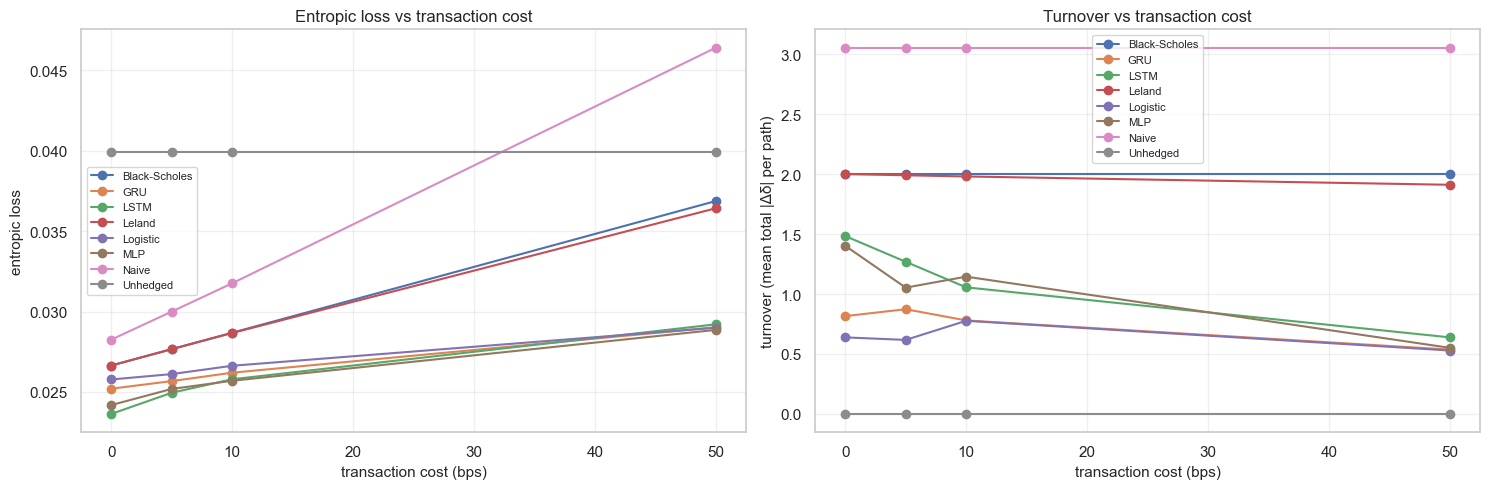

In [33]:
fees = [0.0, 0.0005, 0.001, 0.005]
records = []

for fee in fees:
    rows = run_config(train, test, BEST, mlp_features, rnn_features, fee=fee)
    for row in rows:
        row["fee_bps"] = fee * 1e4
        records.append(row)

df_cost = pd.DataFrame(records)
display(df_cost.pivot_table(index="fee_bps", columns="model",
                            values=["entropic", "turnover"]).round(5))

fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(15, 5))

for name, sub in df_cost.groupby("model"):
    sub = sub.sort_values("fee_bps")
    ax_l.plot(sub["fee_bps"], sub["entropic"], marker="o", label=name)
ax_l.set_xlabel("transaction cost (bps)")
ax_l.set_ylabel("entropic loss")
ax_l.set_title("Entropic loss vs transaction cost")
ax_l.legend(fontsize=8)
ax_l.grid(alpha=0.3)

for name, sub in df_cost.groupby("model"):
    sub = sub.sort_values("fee_bps")
    ax_r.plot(sub["fee_bps"], sub["turnover"], marker="o", label=name)
ax_r.set_xlabel("transaction cost (bps)")
ax_r.set_ylabel("turnover (mean total |Δδ| per path)")
ax_r.set_title("Turnover vs transaction cost")
ax_r.legend(fontsize=8)
ax_r.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### 9.3 Risk aversion sweep

$\lambda$ controls how much the entropic loss punishes the tail versus the mean — small $\lambda$ is close to hedging the *expected* P&L, large $\lambda$ pushes hard against the worst outcomes. BS and Leland don't depend on $\lambda$ at all (their formula has no risk-aversion parameter), so they're re-evaluated rather than re-trained at each grid point — the entropic loss number *reported for them* still changes with $\lambda$ because the loss functional itself changes, even though their delta doesn't.


model,Black-Scholes,GRU,LSTM,Leland,Logistic,MLP,Naive,Unhedged
risk_aversion,,,,,,,,
1,0.02803,0.02085,0.02079,0.02801,0.02122,0.02078,0.02855,0.03079
5,0.02831,0.02407,0.02441,0.02830,0.02434,0.02400,0.02989,0.03431
10,0.02868,0.02594,0.02583,0.02867,0.02654,0.02596,0.03176,0.03991
25,0.02993,0.02947,0.02936,0.02991,0.03107,0.02931,0.03936,0.07411
50,0.03256,0.03554,0.03687,0.03249,0.04595,0.03402,0.06144,0.16961


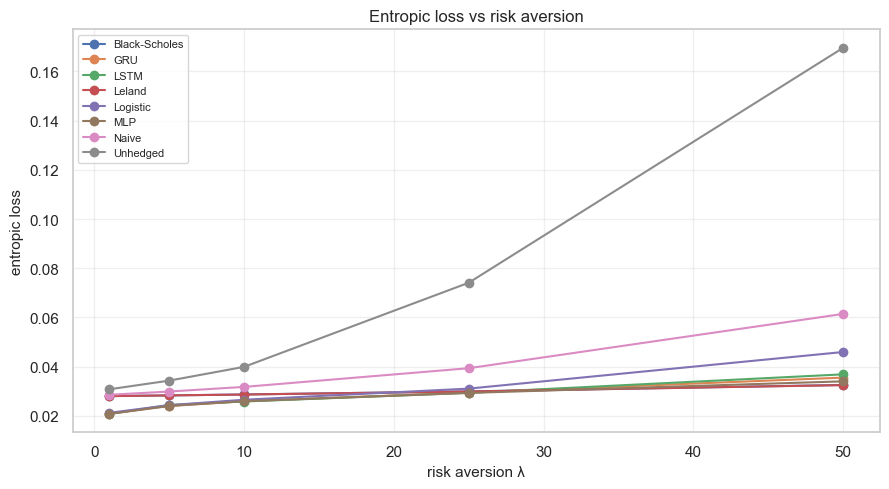

In [34]:
risk_aversions = [1, 5, 10, 25, 50]
records_ra = []

for ra in risk_aversions:
    rows = run_config(train, test, BEST, mlp_features, rnn_features, risk_aversion=ra)
    for row in rows:
        row["risk_aversion"] = ra
        records_ra.append(row)

df_ra = pd.DataFrame(records_ra)
display(df_ra.pivot_table(index="risk_aversion", columns="model", values="entropic").round(5))

plt.figure(figsize=(9, 5))
for name, sub in df_ra.groupby("model"):
    sub = sub.sort_values("risk_aversion")
    plt.plot(sub["risk_aversion"], sub["entropic"], marker="o", label=name)
plt.xlabel("risk aversion λ")
plt.ylabel("entropic loss")
plt.title("Entropic loss vs risk aversion")
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 9.4 Maturity sweep

A different maturity means different-length windows, so this rebuilds `train`/`test` with `build_windows(..., n_steps=n)` for each option lifetime rather than reusing the 30-day windows from Part 0. Volatility is re-estimated on each maturity's own training window (via `run_config`'s `sigma=None` default) rather than reused from the 30-day case, since a different sample of dates could in principle have a different realized vol.


model,Black-Scholes,GRU,LSTM,Leland,Logistic,MLP,Naive,Unhedged
maturity,,,,,,,,
10,0.01661,0.01577,0.01579,0.01660,0.01578,0.01577,0.01799,0.01914
20,0.02341,0.02176,0.02165,0.02340,0.02187,0.02174,0.02559,0.03023
30,0.02868,0.02598,0.02532,0.02867,0.02648,0.02629,0.03176,0.03991
60,0.04036,0.03553,0.03657,0.04032,0.03513,0.03502,0.04632,0.06429


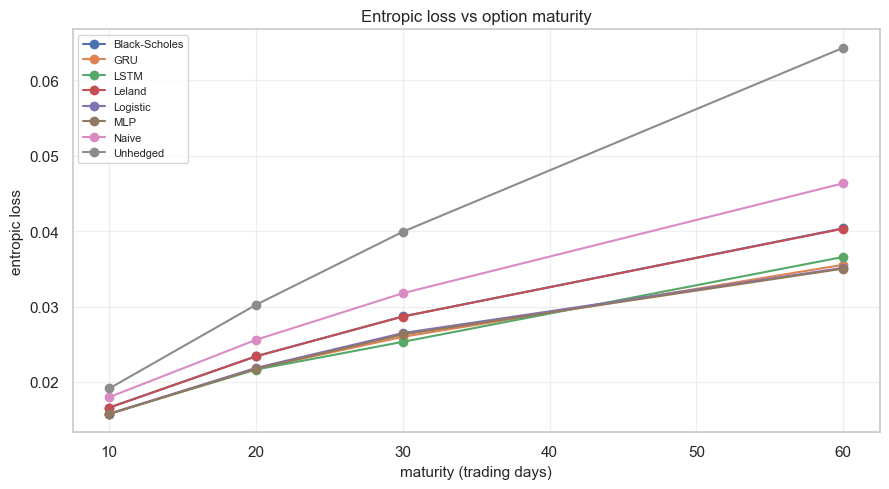

In [35]:
maturities = [10, 20, 30, 60]
records_mat = []

for mat in maturities:
    train_mat, _ = build_windows(price_data, *SPLITS["train"], n_steps=mat)
    test_mat, _  = build_windows(price_data, *SPLITS["test"],  n_steps=mat)

    rng_mat = np.random.default_rng(42)
    rng_mat.shuffle(train_mat)

    rows = run_config(train_mat, test_mat, BEST, mlp_features, rnn_features, n_steps=mat)
    for row in rows:
        row["maturity"] = mat
        records_mat.append(row)

df_mat = pd.DataFrame(records_mat)
display(df_mat.pivot_table(index="maturity", columns="model", values="entropic").round(5))

plt.figure(figsize=(9, 5))
for name, sub in df_mat.groupby("model"):
    sub = sub.sort_values("maturity")
    plt.plot(sub["maturity"], sub["entropic"], marker="o", label=name)
plt.xlabel("maturity (trading days)")
plt.ylabel("entropic loss")
plt.title("Entropic loss vs option maturity")
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
